<a href="https://colab.research.google.com/github/mmarino84719/-MLflow-Tracking---Taller-1/blob/main/Segunda_Entrega_Tesis_LLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle


In [2]:
#Librerias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
#Autenticacion de Kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "https://www.kaggle.com/milenamario",\r\n  "key": "KGAT_72154104ad774a402beaa34e80841ff7"\r\n}'}

In [4]:
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
#Descarga del Dataset
!kaggle datasets download -d mehradaria/leukemia

Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia
License(s): ODbL-1.0
100% 110M/110M [00:05<00:00, 19.4MB/s]



In [6]:
#Descompensión del Archivo Zip
!rm -rf *
!kaggle datasets download -d mehradaria/leukemia
!unzip -o leukemia.zip

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: Original/Pre/WBC-Malignant-Pre-024.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-025.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-026.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-027.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-028.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-029.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-030.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-031.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-032.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-033.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-034.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-035.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-036.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-037.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-038.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-039.jpg  
  inflating: Original/Pre/WBC-Malignant-Pre-040.jpg  
  inflating: Or

In [7]:
#Validación de Carpetas del Zip
!ls

leukemia.zip  Original	Segmented


In [8]:
#Validación de Datos de Carpeta en la que se va a trabajar el modelo
!ls Segmented

Benign	Early  Pre  Pro


In [9]:
#Alineación sin embargo  el dataset ya no trae implicito, se hace la prueba con las dos carpetas
original_path = '/content/Original'
segmented_path = '/content/Segmented'

original_files = set(os.listdir(original_path))
segmented_files = set(os.listdir(segmented_path))

# Intersección (archivos que coinciden)
aligned = original_files.intersection(segmented_files)

print("Total originales:", len(original_files))
print("Total segmentados:", len(segmented_files))
print("Coinciden:", len(aligned))

Total originales: 4
Total segmentados: 4
Coinciden: 4


In [10]:
#Creación del Generador incluyendo Dataaugmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    #  Data Augmentation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1
)

In [11]:
#Datos de Entenamiento
train_data = datagen.flow_from_directory(
    '/content/Segmented',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 2607 images belonging to 4 classes.


In [12]:
#Datos de Validación y codificación de etiquetas
val_data = datagen.flow_from_directory(
    '/content/Segmented',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 649 images belonging to 4 classes.


In [13]:
#Verificación del modelo entrenado
print(train_data.class_indices)

{'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}


In [14]:
#Verificación de cantidad de datos
#Entranmiento 2607 Y validacion 649 lo que suman las 3256 imagenes que contiene el dataset
print("Entrenamiento:", train_data.samples)
print("Validación:", val_data.samples)

Entrenamiento: 2607
Validación: 649


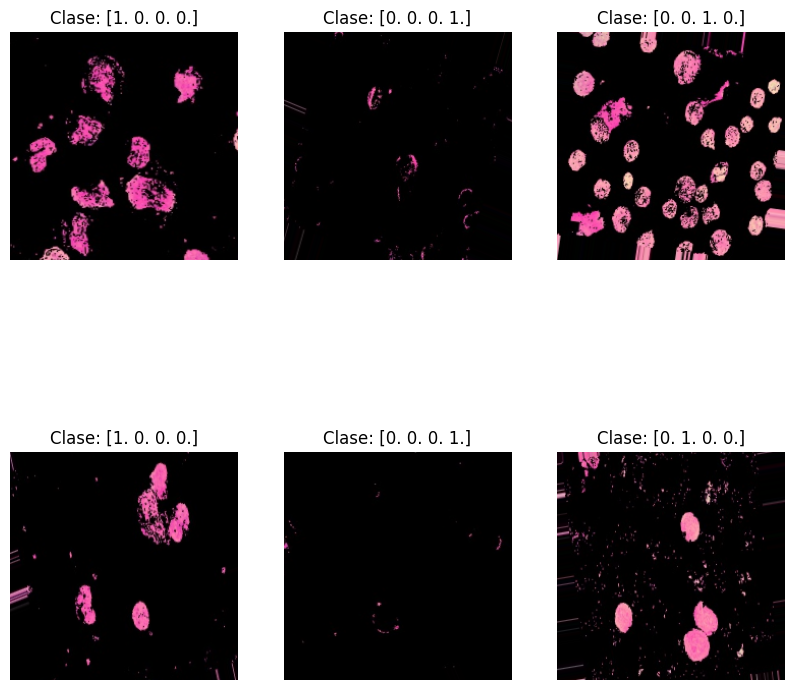

In [15]:
#Visualización de las imagenes con dataaugmentation
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(f"Clase: {labels[i]}")
    plt.axis('off')

plt.show()

In [16]:
#Conteo de clases

labels = train_data.classes
class_names = list(train_data.class_indices.keys())

unique, counts = np.unique(labels, return_counts=True)

for i in range(len(unique)):
    print(f"{class_names[i]}: {counts[i]}")

Benign: 404
Early: 788
Pre: 771
Pro: 644


In [17]:
404+788+771+644


2607

In [18]:
#Balanceo de Clases

labels = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.6132425742574257), 1: np.float64(0.8270939086294417), 2: np.float64(0.8453307392996109), 3: np.float64(1.0120341614906831)}
